# FedProto (Federated Prototype Learning) with Metrics Annealing for Fine-Tuning

### Colab config

In [1]:
# First cell in Colab
from google.colab import drive
drive.mount('/content/drive')

# Check GPU
import torch
print(f"GPU available : {torch.cuda.is_available()}")
print(f"GPU name      : {torch.cuda.get_device_name(0)}")
# Should print: Tesla T4 or similar

# Install dependencies
!pip install torchvision torch -q

Mounted at /content/drive
GPU available : False


AssertionError: Torch not compiled with CUDA enabled

### Setting Working Directory

In [2]:
import os

curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")
os.chdir('/content/drive/MyDrive/BREAST_CANCER_FL/')
print("Changing to root directory...")

print(f"Working in: '{os.getcwd()}'")

Current directory: '/content'
Changing to root directory...
Working in: '/content/drive/MyDrive/BREAST_CANCER_FL'


### Environment Setup & Imports

In [15]:
from google.colab import drive
drive.mount('/content/drive')

import os
import copy
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Set Working Directory
BASE_PATH = '/content/drive/MyDrive/BREAST_CANCER_FL/'
os.chdir(BASE_PATH)
import sys
sys.path.append(BASE_PATH)

from model_architectures import (
    EMBEDDING_DIM,
    Hospital1_MLP, Hospital2_MLP, Hospital3_CNN
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

os.makedirs(os.path.join(BASE_PATH, 'models/federated/fedproto'), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, 'results/federated/fedproto'), exist_ok=True)

print("="*70)
print("  STEP 4 — FedProto (Prototype Representation Sharing) with Fine-Tuning")
print("="*70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Device: cpu
  STEP 4 — FedProto (Prototype Representation Sharing) with Fine-Tuning


### Data Loading

In [16]:
print("Loading Datasets...")

# Hospital 1 — WDBC
X_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_train.csv')).values
y_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_train.csv')).values.flatten()
X_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_test.csv')).values
y_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_test.csv')).values.flatten()

train_dataset_h1 = TensorDataset(torch.FloatTensor(X_train_h1), torch.FloatTensor(y_train_h1))
test_dataset_h1 = TensorDataset(torch.FloatTensor(X_test_h1), torch.FloatTensor(y_test_h1))
train_loader_h1 = DataLoader(train_dataset_h1, batch_size=32, shuffle=True)
test_loader_h1 = DataLoader(test_dataset_h1, batch_size=32, shuffle=False)

# Hospital 2 — Coimbra
X_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_train.csv')).values
y_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_train.csv')).values.flatten()
X_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_test.csv')).values
y_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_test.csv')).values.flatten()

train_dataset_h2 = TensorDataset(torch.FloatTensor(X_train_h2), torch.FloatTensor(y_train_h2))
test_dataset_h2 = TensorDataset(torch.FloatTensor(X_test_h2), torch.FloatTensor(y_test_h2))
train_loader_h2 = DataLoader(train_dataset_h2, batch_size=16, shuffle=True)
test_loader_h2 = DataLoader(test_dataset_h2, batch_size=16, shuffle=False)

# Hospital 3 — BreakHis
class BreakHisDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform  # <-- This line was missing!
        self.images, self.labels = [], []
        for cls, label in [('benign', 0), ('malignant', 1)]:
            cls_dir = os.path.join(root_dir, cls)
            if os.path.exists(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(os.path.join(cls_dir, img_name))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform_h3 = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(), norm
])
test_transform_h3 = transforms.Compose([transforms.ToTensor(), norm])

train_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/train'), transform=train_transform_h3)
test_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/test'), transform=test_transform_h3)

from sklearn.utils.class_weight import compute_class_weight
class_weights_h3 = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=train_dataset_h3.labels)
sample_weights_h3 = [class_weights_h3[l] for l in train_dataset_h3.labels]
sampler_h3 = WeightedRandomSampler(weights=sample_weights_h3, num_samples=len(sample_weights_h3), replacement=True)

# Optimized DataLoaders for CUDA
train_loader_h3 = DataLoader(train_dataset_h3, batch_size=32, sampler=sampler_h3, num_workers=2, pin_memory=True)
test_loader_h3 = DataLoader(test_dataset_h3, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Data successfully loaded and pinned to memory.")

Loading Datasets...
Data successfully loaded and pinned to memory.


### FedProto Utility Functions

In [17]:
def aggregate_prototypes(local_protos_list):
    """
    Averages the class prototypes from all hospitals.
    local_protos_list: List of dictionaries [{0: tensor, 1: tensor}, ...]
    """
    global_protos = {}
    for class_id in [0, 1]:
        class_tensors = [p[class_id] for p in local_protos_list if class_id in p]
        if class_tensors:
            global_protos[class_id] = torch.stack(class_tensors).mean(dim=0)
    return global_protos

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend((outputs > 0.0).float().cpu().numpy())
            all_probs.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels).flatten()
    try: auc = roc_auc_score(all_labels, np.array(all_probs).flatten())
    except ValueError: auc = 0.0

    return {
        'loss': running_loss / len(dataloader.dataset),
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
        'auc_roc': auc
    }

### Load Previous Histories

In [18]:
# Load all previous FL histories for final comparison
with open(
    'results/federated/fl_history.json',
    'r', encoding='utf-8'
) as f:
    fl_history_weighted = json.load(f)

with open(
    'results/federated/equal/fl_history_eq.json',
    'r', encoding='utf-8'
) as f:
    fl_history_equal = json.load(f)

with open(
    'results/federated/fedprox/fl_history_prox.json',
    'r', encoding='utf-8'
) as f:
    fl_history_prox = json.load(f)

with open(
    'results/federated/fedproto/fl_history_fedproto.json',
    'r', encoding='utf-8'
) as f:
    fl_history_proto = json.load(f)

# Best round indices for each method
best_idx_w    = int(np.argmax(fl_history_weighted['avg_test_acc']))
best_idx_eq   = int(np.argmax(fl_history_equal['avg_test_acc']))
best_idx_prox = int(np.argmax(fl_history_prox['avg_test_acc']))
best_idx_proto = int(np.argmax(fl_history_proto['avg_test_acc']))

print(" All FL histories loaded")
print(f"   FedAvg Weighted best H2 : "
      f"{max(fl_history_weighted['h2_test_acc']):.4f}")
print(f"   FedAvg Equal    best H2 : "
      f"{max(fl_history_equal['h2_test_acc']):.4f}")
print(f"   FedProx         best H2 : "
      f"{max(fl_history_prox['h2_test_acc']):.4f}")
print(f"   FedProto        best H2 : "
      f"{max(fl_history_proto['h2_test_acc']):.4f}")
print(f"\n   Baseline to beat        : "
      f"{max(max(fl_history_weighted['h2_test_acc']), max(fl_history_equal['h2_test_acc'])):.4f}")

 All FL histories loaded
   FedAvg Weighted best H2 : 0.7500
   FedAvg Equal    best H2 : 0.7917
   FedProx         best H2 : 0.7917
   FedProto        best H2 : 0.7500

   Baseline to beat        : 0.7917


### Loading Best FedProto Model for Hospital 2

In [19]:
# STEP 4 — FedProto + Fine-Tuning with Metrics Annealing
#
# Strategy:
#   Load best Hospital 2 model from FedProto
#   Fine-tune ONLY the last shared head layer on Coimbra
#   Use prototype-anchored annealing loss:
#     Early epochs → stay close to global prototype knowledge
#     Later epochs → gradually release → pure Coimbra specialization
#
# Two variants compared (sub-ablation):
#   A) Fine-tuning WITHOUT annealing (standard transfer learning)
#   B) Fine-tuning WITH annealing    (prototype-anchored annealing)

import os
import copy
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    classification_report
)

os.makedirs('models/federated/fedproto_ft', exist_ok=True)
os.makedirs('results/federated/fedproto_ft', exist_ok=True)

print("="*70)
print("  STEP 4 — FedProto + Fine-Tuning (Metrics Annealing)")
print("="*70)

# Load best FedProto Hospital 2 model
# This is our starting point for fine-tuning
model_h2_ft = Hospital2_MLP(
    input_size=9, dropout_rate=0.3
).to(device)
model_h2_ft.load_state_dict(
    torch.load(
        'models/federated/fedproto/best_h2_fedproto.pth',
        map_location=device
    )
)
print(" Best FedProto Hospital 2 model loaded")
print(f"   Starting accuracy from FedProto: "
      f"{max(fl_history_proto['h2_test_acc']):.4f}")

# Load global prototypes from FedProto
# Used as anchor during annealing fine-tuning
global_protos = torch.load(
    'models/federated/fedproto/best_global_protos.pth',
    map_location=device
)
benign_proto    = global_protos[0].to(device)
malignant_proto = global_protos[1].to(device)

print(f" Global prototypes loaded")
print(f"   Benign proto shape    : {benign_proto.shape}")
print(f"   Malignant proto shape : {malignant_proto.shape}")
print(f"   Prototype distance    : "
      f"{torch.norm(benign_proto - malignant_proto).item():.4f}")

  STEP 4 — FedProto + Fine-Tuning (Metrics Annealing)
 Best FedProto Hospital 2 model loaded
   Starting accuracy from FedProto: 0.7500
 Global prototypes loaded
   Benign proto shape    : torch.Size([64])
   Malignant proto shape : torch.Size([64])
   Prototype distance    : 3.1206


### Fine-Tuning Helper Functions

In [20]:
# FINE-TUNING HELPER FUNCTIONS

def evaluate_h2(model, dataloader, criterion, device):
    """
    Evaluate Hospital 2 model — returns full metrics dict.
    """
    model.eval()
    running_loss = 0.0
    all_preds    = []
    all_probs    = []
    all_labels   = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs  = inputs.to(device).float()
            labels  = labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            preds = (outputs > 0.0).float()
            probs = torch.sigmoid(outputs)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels).flatten()
    all_preds  = np.array(all_preds).flatten()
    all_probs  = np.array(all_probs).flatten()

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0

    return {
        'loss'     : running_loss / len(dataloader.dataset),
        'accuracy' : accuracy_score(all_labels, all_preds),
        'precision': precision_score(
            all_labels, all_preds, zero_division=0
        ),
        'recall'   : recall_score(
            all_labels, all_preds, zero_division=0
        ),
        'f1'       : f1_score(
            all_labels, all_preds, zero_division=0
        ),
        'auc_roc'  : auc
    }


def prototype_alignment_loss(model, dataloader, device,
                              global_protos):
    """
    Compute prototype alignment loss for current model.
    Measures how far current embeddings are from global prototypes.
    Used as anchor during annealing fine-tuning.
    """
    model.eval()
    total_loss = 0.0
    count      = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).float()

            embeddings = model.encoder(inputs)

            for emb, label in zip(embeddings, labels):
                proto = global_protos[int(label.item())]
                total_loss += (emb - proto).norm().item() ** 2
                count += 1

    return total_loss / count if count > 0 else 0.0


def get_annealing_lambda(epoch, total_epochs,
                          lambda_start=0.5, lambda_end=0.0):
    """
    Linear annealing schedule for prototype alignment weight.
    Starts high (anchored to global knowledge) and decays to 0
    (pure Coimbra specialization) over total_epochs.

    epoch 0         → lambda_start (0.5) — strongly anchored
    epoch total/2   → lambda_start/2     — moderate anchor
    epoch total-1   → lambda_end (0.0)   — fully specialized
    """
    progress = epoch / max(total_epochs - 1, 1)
    return lambda_start * (1.0 - progress) + lambda_end * progress


print(" Fine-tuning helper functions defined")
print("   evaluate_h2()")
print("   prototype_alignment_loss()")
print("   get_annealing_lambda()")
print(f"\n   Annealing schedule preview:")
for ep in [0, 5, 10, 15, 19]:
    lam = get_annealing_lambda(ep, 20)
    print(f"   Epoch {ep:02d} → lambda = {lam:.3f}")

 Fine-tuning helper functions defined
   evaluate_h2()
   prototype_alignment_loss()
   get_annealing_lambda()

   Annealing schedule preview:
   Epoch 00 → lambda = 0.500
   Epoch 05 → lambda = 0.368
   Epoch 10 → lambda = 0.237
   Epoch 15 → lambda = 0.105
   Epoch 19 → lambda = 0.000


### Variant A: Fine-Tuning WITHOUT Annealing

In [21]:
# VARIANT A — Fine-Tuning WITHOUT Annealing
# Standard transfer learning:
#   Freeze all shared head layers except final output layer
#   Train only Linear(32→1) on Coimbra data
#   No prototype alignment loss — pure classification loss
# Purpose: Sub-ablation baseline
print("="*70)
print("  VARIANT A — Fine-Tuning WITHOUT Annealing")
print("="*70)

# Create fresh copy from best FedProto H2 model
model_h2_ft_no_anneal = Hospital2_MLP(
    input_size=9, dropout_rate=0.3
).to(device)
model_h2_ft_no_anneal.load_state_dict(
    torch.load(
        'models/federated/fedproto/best_h2_fedproto.pth',
        map_location=device
    )
)

# Freeze everything except final output layer
# Freeze entire encoder
for param in model_h2_ft_no_anneal.encoder.parameters():
    param.requires_grad = False

# Freeze shared head fc1, bn1, dropout1
for param in model_h2_ft_no_anneal.shared_head.fc1.parameters():
    param.requires_grad = False
for param in model_h2_ft_no_anneal.shared_head.bn1.parameters():
    param.requires_grad = False

# Only output layer is trainable
for param in model_h2_ft_no_anneal.shared_head.output.parameters():
    param.requires_grad = True

# Verify
trainable_params = sum(
    p.numel() for p in model_h2_ft_no_anneal.parameters()
    if p.requires_grad
)
print(f"\n  Frozen    : encoder + shared_head fc1 + bn1")
print(f"  Trainable : shared_head output layer only")
print(f"  Trainable params : {trainable_params} "
      f"(Linear 32→1 = 33 params)")

# Optimizer — only output layer
# Very low LR — fine-grained adaptation
optimizer_no_anneal = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model_h2_ft_no_anneal.parameters()
    ),
    lr=0.0001
)
criterion_ft = nn.BCEWithLogitsLoss()

# Fine-tuning loop — no annealing
ft_epochs_no_anneal = 20
history_no_anneal   = {
    'epoch'   : [],
    'loss'    : [],
    'accuracy': [],
    'f1'      : [],
    'auc_roc' : []
}

print(f"\n  Fine-tuning for {ft_epochs_no_anneal} epochs...")
print(f"  {'Epoch':<8} {'Loss':<10} {'Acc':<10} "
      f"{'F1':<10} {'AUC':<10}")
print(f"  {'─'*48}")

best_acc_no_anneal  = 0.0
best_state_no_anneal = None

for epoch in range(ft_epochs_no_anneal):
    model_h2_ft_no_anneal.train()
    running_loss = 0.0
    all_preds    = []
    all_labels   = []

    for inputs, labels in train_loader_h2:
        inputs = inputs.to(device).float()
        labels = labels.to(device).float().view(-1, 1)

        optimizer_no_anneal.zero_grad(set_to_none=True)
        outputs = model_h2_ft_no_anneal(inputs)

        # Pure classification loss — no prototype anchor
        loss = criterion_ft(outputs, labels)
        loss.backward()
        optimizer_no_anneal.step()

        running_loss += loss.item() * inputs.size(0)
        preds = (outputs.detach() > 0.0).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader_h2.dataset)
    train_acc  = accuracy_score(all_labels, all_preds)

    # Evaluate
    metrics = evaluate_h2(
        model_h2_ft_no_anneal, test_loader_h2,
        criterion_ft, device
    )

    history_no_anneal['epoch'].append(epoch + 1)
    history_no_anneal['loss'].append(metrics['loss'])
    history_no_anneal['accuracy'].append(metrics['accuracy'])
    history_no_anneal['f1'].append(metrics['f1'])
    history_no_anneal['auc_roc'].append(metrics['auc_roc'])

    if metrics['accuracy'] > best_acc_no_anneal:
        best_acc_no_anneal   = metrics['accuracy']
        best_state_no_anneal = copy.deepcopy(
            model_h2_ft_no_anneal.state_dict()
        )

    print(f"  {epoch+1:<8} {metrics['loss']:<10.4f} "
          f"{metrics['accuracy']:<10.4f} "
          f"{metrics['f1']:<10.4f} "
          f"{metrics['auc_roc']:<10.4f}")

# Load best weights
model_h2_ft_no_anneal.load_state_dict(best_state_no_anneal)

print(f"\n   Variant A complete")
print(f"     Best accuracy : {best_acc_no_anneal:.4f}")
print(f"     Best AUC      : {max(history_no_anneal['auc_roc']):.4f}")

torch.save(
    model_h2_ft_no_anneal.state_dict(),
    'models/federated/fedproto_ft/h2_ft_no_anneal.pth'
)
print(f"     Model saved   : h2_ft_no_anneal.pth")

  VARIANT A — Fine-Tuning WITHOUT Annealing

  Frozen    : encoder + shared_head fc1 + bn1
  Trainable : shared_head output layer only
  Trainable params : 33 (Linear 32→1 = 33 params)

  Fine-tuning for 20 epochs...
  Epoch    Loss       Acc        F1         AUC       
  ────────────────────────────────────────────────
  1        0.6126     0.7083     0.7200     0.7343    
  2        0.6138     0.7083     0.7200     0.7343    
  3        0.6089     0.7083     0.7200     0.7203    
  4        0.6099     0.7083     0.7200     0.7273    
  5        0.6110     0.7083     0.7200     0.7343    
  6        0.6131     0.6667     0.6923     0.7413    
  7        0.6099     0.7083     0.7200     0.7273    
  8        0.6168     0.7083     0.7200     0.7273    
  9        0.6116     0.7083     0.7200     0.7203    
  10       0.6105     0.7083     0.7200     0.7343    
  11       0.6139     0.7083     0.7200     0.7413    
  12       0.6144     0.7083     0.7200     0.7133    
  13       0.6172

### Variant B: Fine-Tuning WITH Annealing

In [22]:
# VARIANT B — Fine-Tuning WITH Metrics Annealing
# Prototype-anchored annealing:
#   Same frozen layers as Variant A
#   BUT loss includes prototype alignment term with
#   linearly decaying lambda weight
#
# Loss = cls_loss + lambda(epoch) × proto_alignment_loss
#   epoch 0  → lambda=0.5 (strongly anchored to global knowledge)
#   epoch 19 → lambda=0.0 (pure Coimbra specialization)
#
# This prevents catastrophic forgetting of federated knowledge
# while allowing gradual Coimbra-specific adaptation
print("="*70)
print("  VARIANT B — Fine-Tuning WITH Metrics Annealing")
print("="*70)

# Create fresh copy from best FedProto H2 model
# Same starting point as Variant A — fair comparison
model_h2_ft_anneal = Hospital2_MLP(
    input_size=9, dropout_rate=0.3
).to(device)
model_h2_ft_anneal.load_state_dict(
    torch.load(
        'models/federated/fedproto/best_h2_fedproto.pth',
        map_location=device
    )
)

# Freeze same layers as Variant A
for param in model_h2_ft_anneal.encoder.parameters():
    param.requires_grad = False
for param in model_h2_ft_anneal.shared_head.fc1.parameters():
    param.requires_grad = False
for param in model_h2_ft_anneal.shared_head.bn1.parameters():
    param.requires_grad = False
for param in model_h2_ft_anneal.shared_head.output.parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel() for p in model_h2_ft_anneal.parameters()
    if p.requires_grad
)
print(f"\n  Frozen    : encoder + shared_head fc1 + bn1")
print(f"  Trainable : shared_head output layer only")
print(f"  Trainable params : {trainable_params}")
print(f"\n  Annealing : lambda 0.5 → 0.0 over 20 epochs")

# Optimizer — same as Variant A
optimizer_anneal = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model_h2_ft_anneal.parameters()
    ),
    lr=0.0001
)

# Fine-tuning loop — WITH annealing
ft_epochs_anneal  = 20
lambda_start      = 0.5
lambda_end        = 0.0
history_anneal    = {
    'epoch'    : [],
    'loss'     : [],
    'accuracy' : [],
    'f1'       : [],
    'auc_roc'  : [],
    'lambda'   : [],
    'proto_loss': []
}

print(f"\n  Fine-tuning for {ft_epochs_anneal} epochs...")
print(f"  {'Epoch':<8} {'Lambda':<10} {'ProtoLoss':<12} "
      f"{'Acc':<10} {'F1':<10} {'AUC':<10}")
print(f"  {'─'*60}")

best_acc_anneal   = 0.0
best_state_anneal = None

for epoch in range(ft_epochs_anneal):
    model_h2_ft_anneal.train()
    running_loss  = 0.0
    running_proto = 0.0
    all_preds     = []
    all_labels    = []

    # Compute annealing lambda for this epoch
    current_lambda = get_annealing_lambda(
        epoch, ft_epochs_anneal, lambda_start, lambda_end
    )

    for inputs, labels in train_loader_h2:
        inputs = inputs.to(device).float()
        labels = labels.to(device).float().view(-1, 1)

        optimizer_anneal.zero_grad(set_to_none=True)

        # Forward pass
        outputs    = model_h2_ft_anneal(inputs)
        embeddings = model_h2_ft_anneal.encoder(inputs)

        # Classification loss
        cls_loss = criterion_ft(outputs, labels)

        # Prototype alignment loss
        # Penalizes distance from global prototype per sample
        proto_loss = torch.tensor(0.0, device=device)
        for emb, label in zip(embeddings, labels):
            proto = (
                benign_proto if label.item() < 0.5
                else malignant_proto
            )
            proto_loss += (emb - proto).norm() ** 2
        proto_loss = proto_loss / len(labels)

        # Combined loss with annealing weight
        total_loss = cls_loss + current_lambda * proto_loss

        total_loss.backward()
        optimizer_anneal.step()

        # Track classification loss only
        running_loss  += cls_loss.item() * inputs.size(0)
        running_proto += proto_loss.item()
        preds = (outputs.detach() > 0.0).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    train_loss  = running_loss  / len(train_loader_h2.dataset)
    avg_proto   = running_proto / len(train_loader_h2)

    # Evaluate
    metrics = evaluate_h2(
        model_h2_ft_anneal, test_loader_h2,
        criterion_ft, device
    )

    history_anneal['epoch'].append(epoch + 1)
    history_anneal['loss'].append(metrics['loss'])
    history_anneal['accuracy'].append(metrics['accuracy'])
    history_anneal['f1'].append(metrics['f1'])
    history_anneal['auc_roc'].append(metrics['auc_roc'])
    history_anneal['lambda'].append(current_lambda)
    history_anneal['proto_loss'].append(avg_proto)

    if metrics['accuracy'] > best_acc_anneal:
        best_acc_anneal   = metrics['accuracy']
        best_state_anneal = copy.deepcopy(
            model_h2_ft_anneal.state_dict()
        )

    print(f"  {epoch+1:<8} {current_lambda:<10.3f} "
          f"{avg_proto:<12.4f} "
          f"{metrics['accuracy']:<10.4f} "
          f"{metrics['f1']:<10.4f} "
          f"{metrics['auc_roc']:<10.4f}")

# Load best weights
model_h2_ft_anneal.load_state_dict(best_state_anneal)

print(f"\n   Variant B complete")
print(f"     Best accuracy : {best_acc_anneal:.4f}")
print(f"     Best AUC      : {max(history_anneal['auc_roc']):.4f}")

torch.save(
    model_h2_ft_anneal.state_dict(),
    'models/federated/fedproto_ft/h2_ft_anneal.pth'
)
print(f"     Model saved   : h2_ft_anneal.pth")

  VARIANT B — Fine-Tuning WITH Metrics Annealing

  Frozen    : encoder + shared_head fc1 + bn1
  Trainable : shared_head output layer only
  Trainable params : 33

  Annealing : lambda 0.5 → 0.0 over 20 epochs

  Fine-tuning for 20 epochs...
  Epoch    Lambda     ProtoLoss    Acc        F1         AUC       
  ────────────────────────────────────────────────────────────
  1        0.500      36.9910      0.7083     0.7200     0.7343    
  2        0.474      35.4701      0.7083     0.7200     0.7483    
  3        0.447      36.6211      0.6667     0.6923     0.7273    
  4        0.421      36.8227      0.6667     0.6923     0.7483    
  5        0.395      35.6252      0.6667     0.6923     0.7273    
  6        0.368      36.7399      0.6667     0.6923     0.7203    
  7        0.342      35.9541      0.7083     0.7200     0.7203    
  8        0.316      36.3300      0.7083     0.7200     0.7133    
  9        0.289      36.6587      0.7083     0.7200     0.7063    
  10       0.2

### Sub-Ablation: Annealing vs No Annealing

  SUB-ABLATION — WITH vs WITHOUT Annealing

  Method                                   Acc       F1      AUC
  ───────────────────────────────────────────────────────────
  FedProto (before FT)                  0.7500   0.7500   0.7552
  FedProto + FT (no annealing)          0.7083   0.7200   0.7413
  FedProto + FT (with annealing)        0.7083   0.7200   0.7483
  ───────────────────────────────────────────────────────────

  Delta: FT no anneal vs FedProto baseline:
    Acc : -0.0417
    AUC : -0.0140

  Delta: FT with anneal vs FedProto baseline:
    Acc : -0.0417
    AUC : -0.0070

  Delta: Annealing vs No Annealing:
    Acc : +0.0000
    AUC : +0.0070

  Sub-ablation winner: Annealing


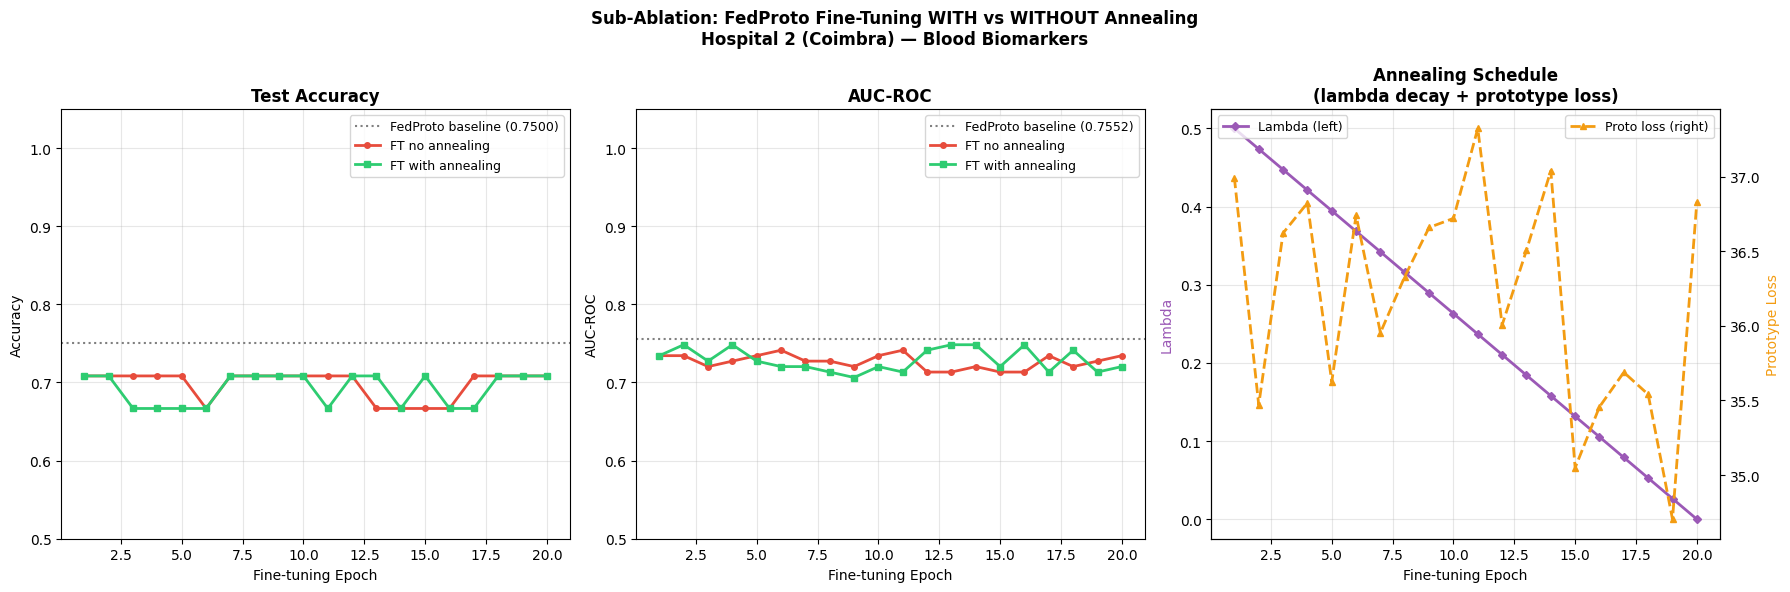


 Sub-ablation plot saved


In [24]:
# SUB-ABLATION — Annealing vs No Annealing
# Direct comparison of the two fine-tuning variants
print("="*70)
print("  SUB-ABLATION — WITH vs WITHOUT Annealing")
print("="*70)

# Numerical comparison
best_no_anneal_acc = max(history_no_anneal['accuracy'])
best_no_anneal_auc = max(history_no_anneal['auc_roc'])
best_no_anneal_f1  = max(history_no_anneal['f1'])

best_anneal_acc = max(history_anneal['accuracy'])
best_anneal_auc = max(history_anneal['auc_roc'])
best_anneal_f1  = max(history_anneal['f1'])

fedproto_baseline_acc = max(fl_history_proto['h2_test_acc'])
fedproto_baseline_auc = max(fl_history_proto['h2_test_auc'])
fedproto_baseline_f1  = max(fl_history_proto['h2_test_f1'])

print(f"\n  {'Method':<35} {'Acc':>8} {'F1':>8} {'AUC':>8}")
print(f"  {'─'*59}")
print(f"  {'FedProto (before FT)':<35} "
      f"{fedproto_baseline_acc:>8.4f} "
      f"{fedproto_baseline_f1:>8.4f} "
      f"{fedproto_baseline_auc:>8.4f}")
print(f"  {'FedProto + FT (no annealing)':<35} "
      f"{best_no_anneal_acc:>8.4f} "
      f"{best_no_anneal_f1:>8.4f} "
      f"{best_no_anneal_auc:>8.4f}")
print(f"  {'FedProto + FT (with annealing)':<35} "
      f"{best_anneal_acc:>8.4f} "
      f"{best_anneal_f1:>8.4f} "
      f"{best_anneal_auc:>8.4f}")
print(f"  {'─'*59}")
print(f"\n  Delta: FT no anneal vs FedProto baseline:")
print(f"    Acc : {best_no_anneal_acc - fedproto_baseline_acc:+.4f}")
print(f"    AUC : {best_no_anneal_auc - fedproto_baseline_auc:+.4f}")
print(f"\n  Delta: FT with anneal vs FedProto baseline:")
print(f"    Acc : {best_anneal_acc - fedproto_baseline_acc:+.4f}")
print(f"    AUC : {best_anneal_auc - fedproto_baseline_auc:+.4f}")
print(f"\n  Delta: Annealing vs No Annealing:")
print(f"    Acc : {best_anneal_acc - best_no_anneal_acc:+.4f}")
print(f"    AUC : {best_anneal_auc - best_no_anneal_auc:+.4f}")

winner = 'Annealing' if best_anneal_acc >= best_no_anneal_acc \
    else 'No Annealing'
print(f"\n  Sub-ablation winner: {winner}")

# Plot — sub-ablation comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Sub-Ablation: FedProto Fine-Tuning WITH vs WITHOUT Annealing\n'
    'Hospital 2 (Coimbra) — Blood Biomarkers',
    fontsize=12, fontweight='bold'
)

epochs_range = history_no_anneal['epoch']

# Accuracy
axes[0].axhline(
    y=fedproto_baseline_acc, color='gray',
    linestyle=':', linewidth=1.5,
    label=f'FedProto baseline ({fedproto_baseline_acc:.4f})'
)
axes[0].plot(
    epochs_range, history_no_anneal['accuracy'],
    color='#E74C3C', linewidth=2,
    marker='o', markersize=4,
    label='FT no annealing'
)
axes[0].plot(
    epochs_range, history_anneal['accuracy'],
    color='#2ECC71', linewidth=2,
    marker='s', markersize=4,
    label='FT with annealing'
)
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_xlabel('Fine-tuning Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.5, 1.05])
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# AUC
axes[1].axhline(
    y=fedproto_baseline_auc, color='gray',
    linestyle=':', linewidth=1.5,
    label=f'FedProto baseline ({fedproto_baseline_auc:.4f})'
)
axes[1].plot(
    epochs_range, history_no_anneal['auc_roc'],
    color='#E74C3C', linewidth=2,
    marker='o', markersize=4,
    label='FT no annealing'
)
axes[1].plot(
    epochs_range, history_anneal['auc_roc'],
    color='#2ECC71', linewidth=2,
    marker='s', markersize=4,
    label='FT with annealing'
)
axes[1].set_title('AUC-ROC', fontweight='bold')
axes[1].set_xlabel('Fine-tuning Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim([0.5, 1.05])
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Lambda decay and proto loss (annealing only)
ax3_twin = axes[2].twinx()
axes[2].plot(
    epochs_range, history_anneal['lambda'],
    color='#9B59B6', linewidth=2,
    marker='D', markersize=4,
    label='Lambda (left)'
)
ax3_twin.plot(
    epochs_range, history_anneal['proto_loss'],
    color='#F39C12', linewidth=2,
    marker='^', markersize=4,
    linestyle='--',
    label='Proto loss (right)'
)
axes[2].set_title(
    'Annealing Schedule\n(lambda decay + prototype loss)',
    fontweight='bold'
)
axes[2].set_xlabel('Fine-tuning Epoch')
axes[2].set_ylabel('Lambda', color='#9B59B6')
ax3_twin.set_ylabel('Prototype Loss', color='#F39C12')
axes[2].legend(loc='upper left', fontsize=9)
ax3_twin.legend(loc='upper right', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    'results/federated/fedproto_ft/sub_ablation_annealing.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print("\n Sub-ablation plot saved")

### Full Five-Method Comparison

  FULL COMPARISON — ALL METHODS (H2 Focus)

  Best FT variant : With Annealing

  Method                                H2 Acc    H2 F1   H2 AUC
  ───────────────────────────────────────────────────────────
  Local Only (Phase 3)                  0.7083   0.6957   0.7692
  FedAvg Weighted                       0.7500   0.7692   0.7552
  FedAvg Equal                          0.7917   0.8148   0.7832 ←
  FedProx                               0.7917   0.8148   0.8182 ←
  FedProto                              0.7500   0.7500   0.7552
  FedProto + FT (With Annealing)        0.7083   0.7200   0.7483


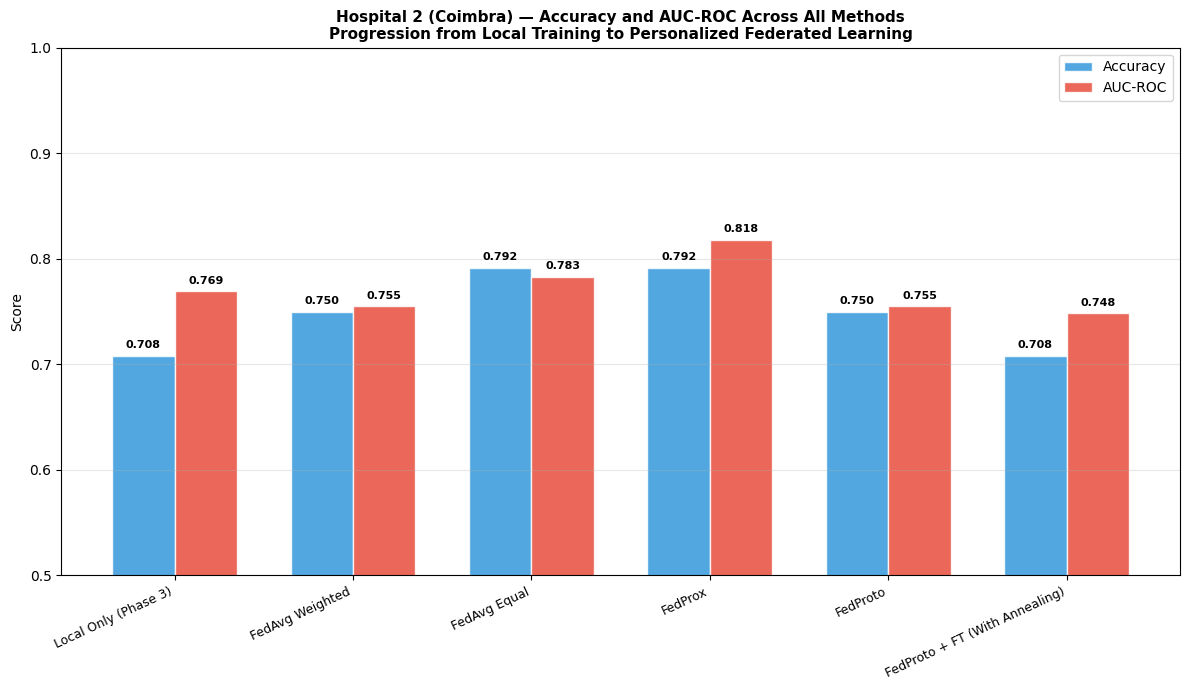


 Full comparison plot saved


In [25]:
# FULL FIVE-METHOD COMPARISON
# All FL methods + best fine-tuning variant for H2
print("="*70)
print("  FULL COMPARISON — ALL METHODS (H2 Focus)")
print("="*70)

# Best fine-tuning result
best_ft_acc = max(best_anneal_acc, best_no_anneal_acc)
best_ft_auc = max(best_anneal_auc, best_no_anneal_auc)
best_ft_f1  = max(best_anneal_f1, best_no_anneal_f1)
best_ft_variant = 'With Annealing' \
    if best_anneal_acc >= best_no_anneal_acc \
    else 'Without Annealing'

print(f"\n  Best FT variant : {best_ft_variant}")

print(f"\n  {'Method':<35} {'H2 Acc':>8} {'H2 F1':>8} {'H2 AUC':>8}")
print(f"  {'─'*59}")

methods = [
    ('Local Only (Phase 3)',
     0.7083, 0.6957, 0.7692),
    ('FedAvg Weighted',
     max(fl_history_weighted['h2_test_acc']),
     max(fl_history_weighted['h2_test_f1']),
     max(fl_history_weighted['h2_test_auc'])),
    ('FedAvg Equal',
     max(fl_history_equal['h2_test_acc']),
     max(fl_history_equal['h2_test_f1']),
     max(fl_history_equal['h2_test_auc'])),
    ('FedProx',
     max(fl_history_prox['h2_test_acc']),
     max(fl_history_prox['h2_test_f1']),
     max(fl_history_prox['h2_test_auc'])),
    ('FedProto',
     max(fl_history_proto['h2_test_acc']),
     max(fl_history_proto['h2_test_f1']),
     max(fl_history_proto['h2_test_auc'])),
    (f'FedProto + FT ({best_ft_variant})',
     best_ft_acc, best_ft_f1, best_ft_auc),
]

for name, acc, f1, auc in methods:
    best_acc_all = max(m[1] for m in methods)
    marker = ' ←' if acc == best_acc_all else ''
    print(f"  {name:<35} {acc:>8.4f} {f1:>8.4f} {auc:>8.4f}{marker}")

# Plot — H2 progression across all methods
fig, ax = plt.subplots(figsize=(12, 7))

method_names = [m[0] for m in methods]
accs         = [m[1] for m in methods]
aucs         = [m[3] for m in methods]

x     = np.arange(len(method_names))
width = 0.35

bars_acc = ax.bar(
    x - width/2, accs, width,
    label='Accuracy', color='#3498DB',
    alpha=0.85, edgecolor='white'
)
bars_auc = ax.bar(
    x + width/2, aucs, width,
    label='AUC-ROC', color='#E74C3C',
    alpha=0.85, edgecolor='white'
)

for bars in [bars_acc, bars_auc]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height + 0.005,
            f'{height:.3f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

ax.set_title(
    'Hospital 2 (Coimbra) — Accuracy and AUC-ROC Across All Methods\n'
    'Progression from Local Training to Personalized Federated Learning',
    fontsize=11, fontweight='bold'
)
ax.set_xticks(x)
ax.set_xticklabels(
    method_names,
    rotation=25, ha='right', fontsize=9
)
ax.set_ylabel('Score')
ax.set_ylim([0.5, 1.0])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    'results/federated/fedproto_ft/h2_all_methods_comparison.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print("\n Full comparison plot saved")

### Save Results and Summary

In [27]:

# SAVE ALL RESULTS

# Save fine-tuning histories
def to_serializable(history):
    return {
        k: [float(v) for v in vals]
        for k, vals in history.items()
    }

with open(
    'results/federated/fedproto_ft/history_no_anneal.json',
    'w', encoding='utf-8'
) as f:
    json.dump(to_serializable(history_no_anneal), f, indent=4)

with open(
    'results/federated/fedproto_ft/history_anneal.json',
    'w', encoding='utf-8'
) as f:
    json.dump(to_serializable(history_anneal), f, indent=4)

print(" Histories saved")

# Summary
summary = f"""
======================================================================
  STEP 4 COMPLETE — FedProto + Fine-Tuning with Metrics Annealing
======================================================================

Fine-tuning configuration:
  Base model       : Best FedProto Hospital 2
  Frozen layers    : Encoder + Shared Head fc1 + bn1
  Trainable layers : Shared Head output (Linear 32→1 = 33 params)
  Optimizer        : Adam (lr=0.0001)
  Epochs           : 20

SUB-ABLATION — Annealing vs No Annealing:
  Method                            Acc      F1      AUC
  FedProto baseline               {fedproto_baseline_acc:.4f}   {fedproto_baseline_f1:.4f}   {fedproto_baseline_auc:.4f}
  FT without annealing            {best_no_anneal_acc:.4f}   {best_no_anneal_f1:.4f}   {best_no_anneal_auc:.4f}
  FT with annealing               {best_anneal_acc:.4f}   {best_anneal_f1:.4f}   {best_anneal_auc:.4f}

  Winner : {winner}
  Annealing delta vs no annealing : Acc={best_anneal_acc-best_no_anneal_acc:+.4f} AUC={best_anneal_auc-best_no_anneal_auc:+.4f}

FULL H2 PROGRESSION:
  Local Only          : 0.7083
  FedAvg Weighted     : {max(fl_history_weighted['h2_test_acc']):.4f}
  FedAvg Equal        : {max(fl_history_equal['h2_test_acc']):.4f}
  FedProx             : {max(fl_history_prox['h2_test_acc']):.4f}
  FedProto            : {max(fl_history_proto['h2_test_acc']):.4f}
  FedProto + FT ({best_ft_variant}): {best_ft_acc:.4f}

Saved files:
  models/federated/fedproto_ft/h2_ft_no_anneal.pth
  models/federated/fedproto_ft/h2_ft_anneal.pth
  results/federated/fedproto_ft/history_no_anneal.json
  results/federated/fedproto_ft/history_anneal.json
  results/federated/fedproto_ft/sub_ablation_annealing.png
  results/federated/fedproto_ft/h2_all_methods_comparison.png

Next: Step 5 — Differential Privacy
======================================================================
"""

print(summary)

with open(
    'results/federated/fedproto_ft/step4_summary.txt',
    'w', encoding='utf-8'
) as f:
    f.write(summary)

print(" Summary saved: results/federated/fedproto_ft/step4_summary.txt")

 Histories saved

  STEP 4 COMPLETE — FedProto + Fine-Tuning with Metrics Annealing

Fine-tuning configuration:
  Base model       : Best FedProto Hospital 2
  Frozen layers    : Encoder + Shared Head fc1 + bn1
  Trainable layers : Shared Head output (Linear 32→1 = 33 params)
  Optimizer        : Adam (lr=0.0001)
  Epochs           : 20

SUB-ABLATION — Annealing vs No Annealing:
  Method                            Acc      F1      AUC
  FedProto baseline               0.7500   0.7500   0.7552
  FT without annealing            0.7083   0.7200   0.7413
  FT with annealing               0.7083   0.7200   0.7483

  Winner : Annealing
  Annealing delta vs no annealing : Acc=+0.0000 AUC=+0.0070

FULL H2 PROGRESSION:
  Local Only          : 0.7083
  FedAvg Weighted     : 0.7500
  FedAvg Equal        : 0.7917
  FedProx             : 0.7917
  FedProto            : 0.7500
  FedProto + FT (With Annealing): 0.7083

Saved files:
  models/federated/fedproto_ft/h2_ft_no_anneal.pth
  models/federated/